In [25]:
from langchain_core.messages import HumanMessage, AIMessage,SystemMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.chat_models import ChatOllama as ol 
from langchain_core.output_parsers import StrOutputParser,PydanticOutputParser

llm=ol(model="deepseek-r1:1.5b")

# **SQL DATABASE AGENT**

In [26]:
from langchain_community.utilities.sql_database import SQLDatabase
sqldb=SQLDatabase.from_uri("sqlite:///sDB/Sales.db")

In [27]:
from langchain_community.agent_toolkits.sql.toolkit import SQLDatabaseToolkit
toolkit=SQLDatabaseToolkit(db=sqldb ,llm=llm)
toolkit.get_tools()

[QuerySQLDatabaseTool(description="Input to this tool is a detailed and correct SQL query, output is a result from the database. If the query is not correct, an error message will be returned. If an error is returned, rewrite the query, check the query, and try again. If you encounter an issue with Unknown column 'xxxx' in 'field list', use sql_db_schema to query the correct table fields.", db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x12463cfc0>),
 InfoSQLDatabaseTool(description='Input to this tool is a comma-separated list of tables, output is the schema and sample rows for those tables. Be sure that the tables actually exist by calling sql_db_list_tables first! Example Input: table1, table2, table3', db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x12463cfc0>),
 ListSQLDatabaseTool(db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x12463cfc0>),
 QuerySQLCheckerTool(description='Use this tool to double check if your 

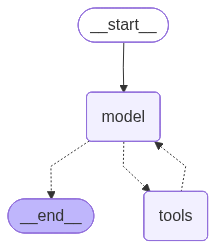

In [28]:
from langchain.agents import create_agent
agent=create_agent(llm,toolkit.get_tools())
agent

In [ ]:
example_query = "How much total sales for banana?"
events = agent.stream(
    {"messages": [("user", example_query)]}, 
    stream_mode="values",
)
for event in events:
    event["messages"][-1].pretty_print()

NotImplementedError: 